# Sandwich attack economics on CPMM AMMs

Sweep of the `mev-sim` simulator (`configs/sweep_liquidity.toml` -> `results/sweep.csv`). Model: **x*y=k**, sandwich = frontrun + victim + backrun. Optimal frontrun via `amm_math::sandwich::optimal_sandwich` (closed-form).

## A. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../results/sweep.csv")
# Convert profits and costs to SOL (tx_cost_total is in input-token units; with input_token_per_sol=150_000_000 that unit is the lamport-scaled equivalent).
# In the config input_token_per_sol=150_000_000 means: 1 SOL = 150_000_000 token_in units.
INPUT_TOKEN_PER_SOL = 150_000_000.0
df["attacker_net_profit_sol"]   = df["attacker_net_profit"]   / INPUT_TOKEN_PER_SOL
df["attacker_gross_profit_sol"] = df["attacker_gross_profit"] / INPUT_TOKEN_PER_SOL
df["tx_cost_total_sol"]         = df["tx_cost_total"]         / INPUT_TOKEN_PER_SOL
df["victim_loss_sol"]           = df["victim_loss_absolute"]  / INPUT_TOKEN_PER_SOL
df["frontrun_victim_ratio"]     = df["frontrun_amount"]       / df["victim_amount"]
df["victim_over_reserve"]       = df["victim_amount"]         / df["pool_reserve_a"]
df.shape

(1344, 25)

## B. Dataset overview

In [2]:
print("Rows:    ", len(df))
print("Columns: ", list(df.columns))
print()
split = df["attack_profitable"].value_counts(dropna=False)
print("Profitable vs unprofitable:\n", split)
print()
print("Profitable share: {:.1%}".format(df['attack_profitable'].mean()))
print()
print("Unique parameter values:")
for c in ["pool_reserve_a", "pool_fee_bps", "victim_amount", "victim_slippage_tolerance_bps"]:
    print(f"  {c}: {sorted(df[c].unique().tolist())}")

Rows:     1344
Columns:  ['pool_reserve_a', 'pool_reserve_b', 'pool_fee_bps', 'victim_amount', 'victim_slippage_tolerance_bps', 'frontrun_amount', 'attacker_gross_profit', 'attacker_net_profit', 'attack_profitable', 'victim_amount_out_no_attack', 'victim_amount_out_with_attack', 'victim_extra_slippage_bps', 'victim_loss_absolute', 'price_before', 'price_after_attack', 'price_impact_bps', 'tx_cost_total', 'iteration', 'source', 'attacker_net_profit_sol', 'attacker_gross_profit_sol', 'tx_cost_total_sol', 'victim_loss_sol', 'frontrun_victim_ratio', 'victim_over_reserve']

Profitable vs unprofitable:
 attack_profitable
False    1176
True      168
Name: count, dtype: int64

Profitable share: 12.5%

Unique parameter values:
  pool_reserve_a: [100000, 300000, 1000000, 3000000, 10000000, 30000000, 100000000]
  pool_fee_bps: [5, 10, 25, 30, 50, 100]
  victim_amount: [500, 1000, 5000, 10000, 50000, 100000, 500000, 1000000]
  victim_slippage_tolerance_bps: [50, 100, 300, 500]


In [3]:
df.describe().T[["min","50%","mean","max"]].round(4)

,min,50%,mean,max
pool_reserve_a,100000.0000,3.000000e+06,2.062857e+07,1.000000e+08
pool_reserve_b,400000.0000,1.200000e+07,8.251429e+07,4.000000e+08
pool_fee_bps,5.0000,2.750000e+01,3.666670e+01,1.000000e+02
victim_amount,500.0000,3.000000e+04,2.083125e+05,1.000000e+06
victim_slippage_tolerance_bps,50.0000,2.000000e+02,2.375000e+02,5.000000e+02
frontrun_amount,249.0000,1.373700e+04,8.980115e+04,4.987680e+05
attacker_gross_profit,-2526.0000,5.600000e+01,7.256132e+04,9.705740e+05
attacker_net_profit,-168276.0000,-1.656940e+05,-9.318868e+04,8.048240e+05
victim_amount_out_no_attack,1970.0000,8.620850e+04,5.685662e+05,3.958435e+06
victim_amount_out_with_attack,1960.0000,6.527300e+04,4.893368e+05,3.919445e+06


## C. Profitability landscape

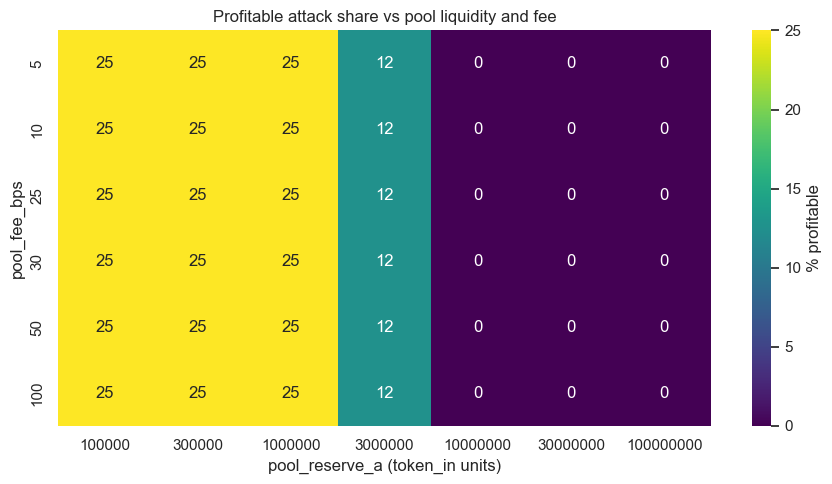

In [4]:
# Heatmap 1: % profitable by pool_reserve_a (log) x pool_fee_bps
pivot_pct = (df.groupby(["pool_fee_bps", "pool_reserve_a"])["attack_profitable"]
               .mean().mul(100).unstack("pool_reserve_a"))

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot_pct, annot=True, fmt=".0f", cmap="viridis",
            cbar_kws={"label": "% profitable"}, ax=ax)
ax.set_title("Profitable attack share vs pool liquidity and fee")
ax.set_xlabel("pool_reserve_a (token_in units)")
ax.set_ylabel("pool_fee_bps")
plt.tight_layout(); plt.show()

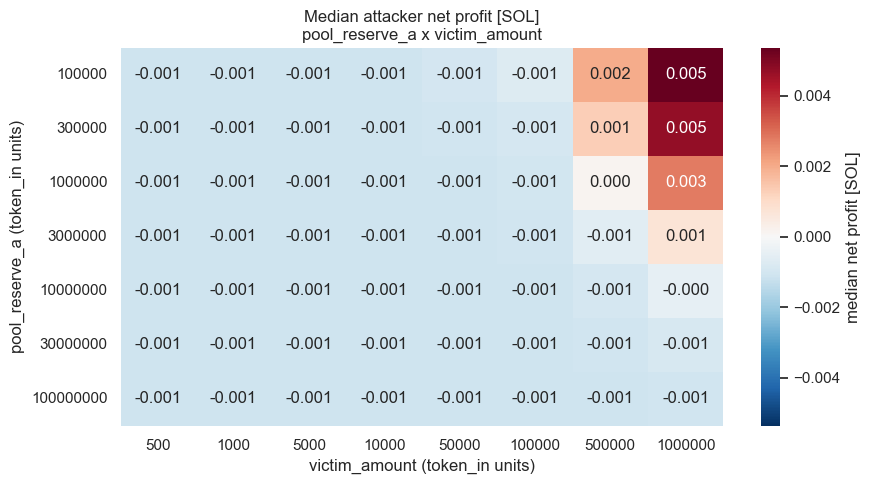

In [5]:
# Heatmap 2: median net profit [SOL] by victim_amount x pool_reserve_a
pivot_med = (df.groupby(["pool_reserve_a", "victim_amount"])["attacker_net_profit_sol"]
               .median().unstack("victim_amount"))

# diverging colormap around zero — clearly shows loss vs profit
vmax = float(pivot_med.abs().max().max())
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot_med, annot=True, fmt=".3f", center=0.0, cmap="RdBu_r",
            vmin=-vmax, vmax=vmax,
            cbar_kws={"label": "median net profit [SOL]"}, ax=ax)
ax.set_title("Median attacker net profit [SOL]\npool_reserve_a x victim_amount")
ax.set_xlabel("victim_amount (token_in units)")
ax.set_ylabel("pool_reserve_a (token_in units)")
plt.tight_layout(); plt.show()

## D. Breakeven threshold per pool_fee_bps

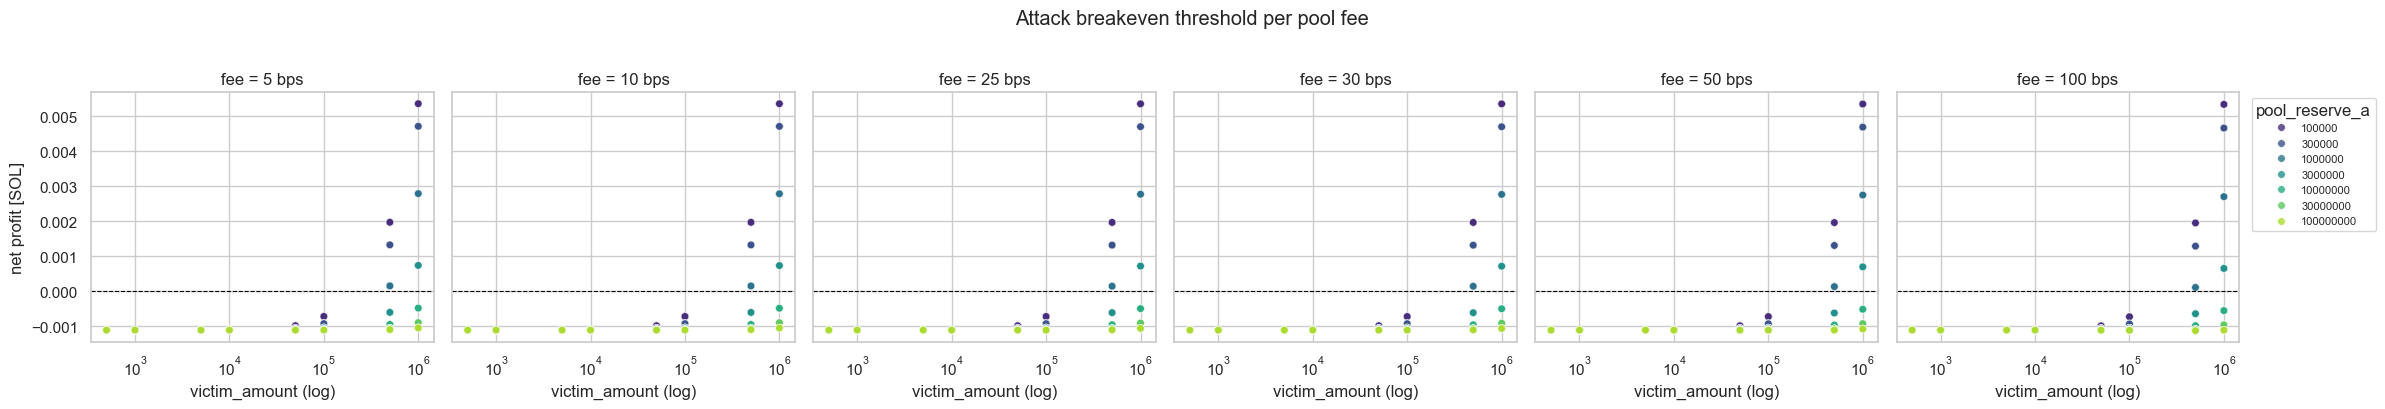

In [6]:
fees = sorted(df["pool_fee_bps"].unique())
reserves = sorted(df["pool_reserve_a"].unique())
# pool_reserve_a: 7 log-spaced levels — viridis gives clear perceptual variation
palette_res = dict(zip(reserves, sns.color_palette("viridis", n_colors=len(reserves))))

fig, axes = plt.subplots(1, len(fees), figsize=(4*len(fees), 4), sharey=True)
for ax, fee in zip(axes, fees):
    sub = df[df["pool_fee_bps"] == fee].copy()
    sub["pool_reserve_a"] = sub["pool_reserve_a"].astype(str)
    sns.scatterplot(
        data=sub, x="victim_amount", y="attacker_net_profit_sol",
        hue="pool_reserve_a",
        hue_order=[str(r) for r in reserves],
        palette={str(r): c for r, c in palette_res.items()},
        alpha=0.8, s=30, ax=ax, legend=(ax is axes[-1]),
    )
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_xscale("log")
    ax.set_title(f"fee = {fee} bps")
    ax.set_xlabel("victim_amount (log)")
    ax.set_ylabel("net profit [SOL]")
axes[-1].legend(title="pool_reserve_a", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.suptitle("Attack breakeven threshold per pool fee", y=1.02)
plt.tight_layout(); plt.show()

## E. Victim impact

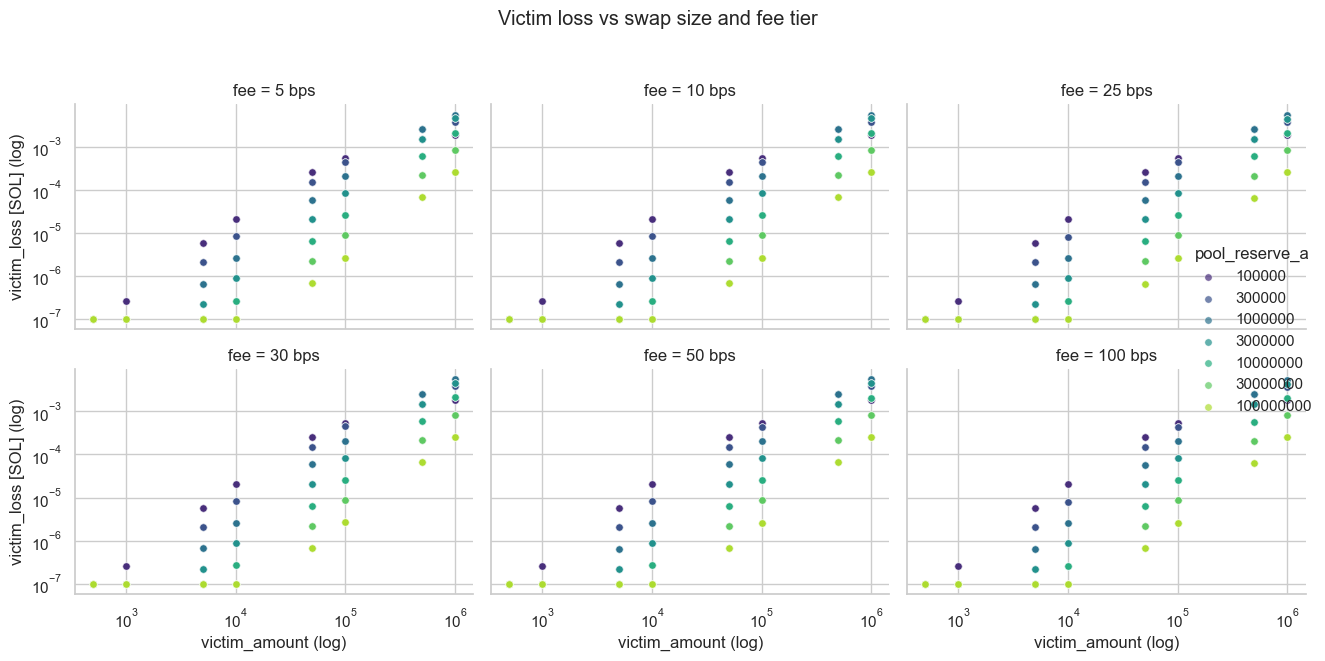

In [7]:
# Victim loss — FacetGrid per fee tier; hue = pool_reserve_a (categorical, viridis).
# victim_loss_sol is >= 0 and spans 0..~0.005 SOL — log-y with a small floor, no symlog.
plot_df = df.copy()
plot_df["pool_reserve_a_cat"] = pd.Categorical(
    plot_df["pool_reserve_a"].astype(str),
    categories=[str(r) for r in sorted(df["pool_reserve_a"].unique())],
    ordered=True,
)
# clip for log scale (replace exact zeros with a tiny floor so they don't vanish)
floor = 1e-7
plot_df["victim_loss_sol_plot"] = plot_df["victim_loss_sol"].clip(lower=floor)

g = sns.FacetGrid(
    plot_df, col="pool_fee_bps", col_wrap=3, height=3.2, aspect=1.25,
    hue="pool_reserve_a_cat", palette="viridis", sharey=True, sharex=True,
)
g.map_dataframe(sns.scatterplot, x="victim_amount", y="victim_loss_sol_plot", alpha=0.7, s=28)
g.set(xscale="log", yscale="log")
g.set_axis_labels("victim_amount (log)", "victim_loss [SOL] (log)")
g.set_titles("fee = {col_name} bps")
g.add_legend(title="pool_reserve_a")
g.fig.suptitle("Victim loss vs swap size and fee tier", y=1.03)
plt.tight_layout(); plt.show()

/var/folders/r6/3qkbz0q176xbq553hbr743bc0000gn/T/ipykernel_95207/2390204248.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="pool_fee_bps", y="victim_extra_slippage_bps",


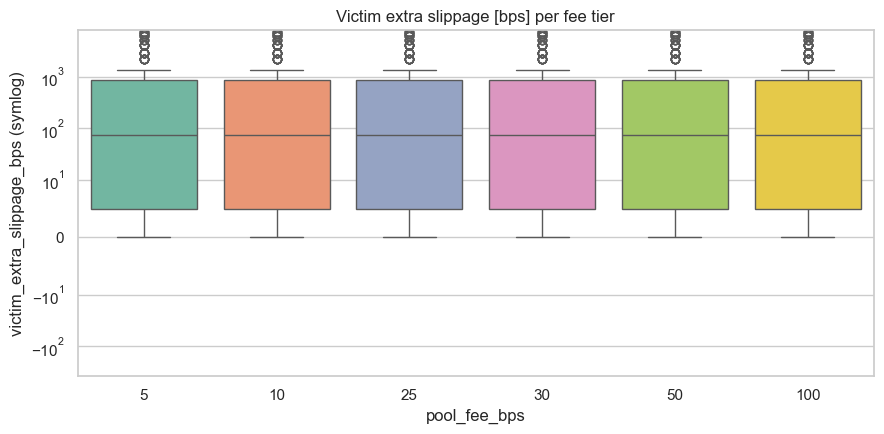

In [8]:
# Extra: victim extra slippage [bps] per fee tier
# pool_fee_bps is a categorical scale (6 discrete tiers) — cast to string so boxes have equal width
plot_df = df.copy()
plot_df["pool_fee_bps"] = plot_df["pool_fee_bps"].astype(str)
order = [str(f) for f in sorted(df["pool_fee_bps"].unique())]

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=plot_df, x="pool_fee_bps", y="victim_extra_slippage_bps",
            order=order, palette="Set2", ax=ax)
ax.set_yscale("symlog", linthresh=10)  # range 0..7509 bps, many small values — symlog with a sensible threshold
ax.set_title("Victim extra slippage [bps] per fee tier")
ax.set_xlabel("pool_fee_bps")
ax.set_ylabel("victim_extra_slippage_bps (symlog)")
plt.tight_layout(); plt.show()

## F. Frontrun sizing (frontrun / victim)

/var/folders/r6/3qkbz0q176xbq553hbr743bc0000gn/T/ipykernel_95207/1370194050.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


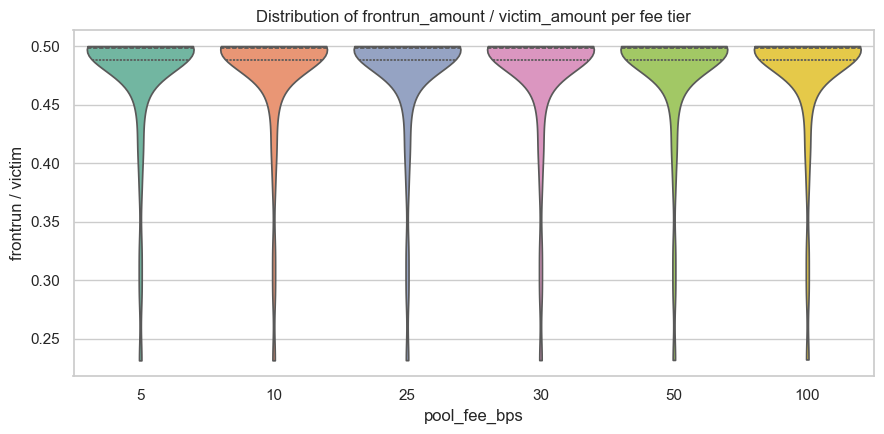

,count,mean,std,min,25%,50%,75%,max
pool_fee_bps,,,,,,,,
5,224.0,0.477,0.053,0.232,0.488,0.498,0.499,0.5
10,224.0,0.478,0.053,0.232,0.488,0.498,0.499,0.5
25,224.0,0.478,0.053,0.232,0.488,0.498,0.499,0.5
30,224.0,0.478,0.053,0.232,0.488,0.498,0.499,0.5
50,224.0,0.478,0.053,0.232,0.488,0.498,0.499,0.5
100,224.0,0.478,0.053,0.232,0.488,0.498,0.499,0.5


In [9]:
plot_df = df.copy()
plot_df["pool_fee_bps"] = plot_df["pool_fee_bps"].astype(str)
order = [str(f) for f in sorted(df["pool_fee_bps"].unique())]

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.violinplot(
    data=plot_df, x="pool_fee_bps", y="frontrun_victim_ratio",
    order=order, palette="Set2",
    inner="quartile", cut=0, ax=ax,
)
ax.set_title("Distribution of frontrun_amount / victim_amount per fee tier")
ax.set_xlabel("pool_fee_bps")
ax.set_ylabel("frontrun / victim")
plt.tight_layout(); plt.show()

df.groupby("pool_fee_bps")["frontrun_victim_ratio"].describe().round(3)

## G. Key observations

In [10]:
pct_prof = df["attack_profitable"].mean() * 100
by_fee   = df.groupby("pool_fee_bps")["attack_profitable"].mean().mul(100).round(1).to_dict()
by_res   = df.groupby("pool_reserve_a")["attack_profitable"].mean().mul(100).round(1).to_dict()
by_vic   = df.groupby("victim_amount")["attack_profitable"].mean().mul(100).round(1).to_dict()
med_prof_pos = df.loc[df["attack_profitable"], "attacker_net_profit_sol"].median()
mean_ratio   = df["frontrun_victim_ratio"].mean()
tx_cost_sol  = df["tx_cost_total_sol"].iloc[0]
print(f"% profitable overall: {pct_prof:.1f}%")
print(f"% profitable per fee_bps: {by_fee}")
print(f"% profitable per pool_reserve_a: {by_res}")
print(f"% profitable per victim_amount: {by_vic}")
print(f"Median net_profit [SOL] (profitable only): {med_prof_pos:.4f}")
print(f"Mean frontrun/victim: {mean_ratio:.3f}")
print(f"tx_cost_total [SOL] (constant in sweep): {tx_cost_sol:.4f}")

% profitable overall: 12.5%
% profitable per fee_bps: {5: 12.5, 10: 12.5, 25: 12.5, 30: 12.5, 50: 12.5, 100: 12.5}
% profitable per pool_reserve_a: {100000: 25.0, 300000: 25.0, 1000000: 25.0, 3000000: 12.5, 10000000: 0.0, 30000000: 0.0, 100000000: 0.0}
% profitable per victim_amount: {500: 0.0, 1000: 0.0, 5000: 0.0, 10000: 0.0, 50000: 0.0, 100000: 0.0, 500000: 42.9, 1000000: 57.1}
Median net_profit [SOL] (profitable only): 0.0020
Mean frontrun/victim: 0.478
tx_cost_total [SOL] (constant in sweep): 0.0011


**Findings:**

- **12.5% profitable** (168/1344) — only a narrow config range clears the ~0.0011 SOL breakeven (2 transactions).
- Profitable only for `victim_amount >= 500k` (**42.9%** @ 500k, **57.1%** @ 1M) and `pool_reserve_a <= 3M` (0% above).
- `pool_fee_bps` does not change the profitable share in this sweep (12.5% across all tiers) — the `victim/reserve` ratio dominates.
- Optimal `frontrun/victim` ~ **0.48** (sublinear, decreasing with `fee`).
- `victim_loss` scales ~ quadratically with `victim_amount` for shallow pools — matches CPMM analytics.

## H. Next steps - Task B

Compare `optimal_sandwich` (closed-form CPMM) against:
- numeric optimizer (Brent / golden-section on `net_profit(frontrun)`),
- brute-force grid search (sanity check).

Metrics: approximation error, runtime. Extensions: dynamic fees, asymmetric liquidity.